# POC Model
- Initial stock ranking model within-portfolio

## Things to Test
- Which response variable and model structure?
    - Structure
        - Simple saturated model with 1 Train and Test (Up to 2024, 2024 to present)
    - Types
        - Decile rank model
        - Lambda rank model
        - Regression Model (_tweedie or weighted MSE_)
- CV Structure
    - Coarse grain search using ~5-10 fold expanding window CV 
        - Ensure coverage of large regime shifts (dotcom, 2008, COVID, etc.)
    - Fine grain search using full expanding window (~20 folds)
        - Train on 15-30 years, Validate on next year, Test on following year
        - Track performance on each test set and diff between test and holdout
            - Log loss, IC, maybe top/bottom decile spread and top decile returns
    
- Variable Selection
    - Based on SHAP and temporal signal consistency

- Models
    - XGBoost as initial model
    - 2 Neural Networks (Shallow and Deep)
    - Hidden Markov regime model

In [37]:
# %pip install matplotlib
# %pip install xgboost==3.0.2

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from importlib import reload 

from src.features.gkx_registry import GKX_94
from src.backtest import (
    Backtester,
    LongOnlyTopPct,
    LongShortTopBottom,
    RegimeConditionalStrategy,
    CashStrategy,
    plot_cumulative_returns,
    plot_drawdown,
    plot_turnover,
    plot_rolling_sharpe,
    plot_monthly_returns_heatmap,
    create_backtest_report,
    print_metrics_comparison,
)

<module 'src.backtest' from 'c:\\Users\\amsac\\Desktop\\repos\\multimodal-stock-ranking\\notebooks\\..\\src\\backtest\\__init__.py'>

In [2]:
run_tag = "run_5000_nonetf_1990"
gkx_path = f"../data/processed/{run_tag}/gkx_monthly.parquet"
daily_path = f"../data/processed/{run_tag}/final_dataset.parquet"
out_path = f"../data/processed/{run_tag}/modeling_monthly_gkx_macro_excess.parquet"

gkx = pd.read_parquet(gkx_path)  # ticker, month_end, GKX vars (+ optional csnorm/csrank)

daily = pd.read_parquet(daily_path)

# Fix columns with "_y" and "_x" suffixes
daily.drop(columns=[col for col in daily.columns if col.endswith("_x")], inplace=True)
daily.columns = [col.replace("_y", "") for col in daily.columns]

daily["date"] = pd.to_datetime(daily["date"])
daily["month_end"] = daily["date"] + pd.offsets.MonthEnd(0)

# Month-end close per ticker
px_m = (
    daily.sort_values(["ticker", "date"])
    .groupby(["ticker", "month_end"], as_index=False)
    .tail(1)[["ticker", "month_end", "close"]]
)

# Stock next-month return
px_m = px_m.sort_values(["ticker", "month_end"])
px_m["ret_eom_t+1"] = px_m.groupby("ticker")["close"].shift(-1) / px_m["close"] - 1

# SPY next-month return (benchmark)
spy = px_m.loc[px_m["ticker"] == "SPY", ["month_end", "ret_eom_t+1"]].rename(
    columns={"ret_eom_t+1": "spy_ret_eom_t+1"}
)

# FRED macro (same for all tickers) at month-end
id_cols = {"ticker", "date", "month_end", "open", "high", "low", "close", "volume"}
macro_cols = [
    'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL', 
    'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO', 
    'UNRATE', 'PAYEMS', 'ICSA', 'UMCSENT', 'RSXFS',
    'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL'
]

macro_m = (
    daily.sort_values("date")
    .groupby("month_end", as_index=False)
    .tail(1)[["month_end"] + macro_cols]
    .drop_duplicates("month_end")
)

# Build modeling table
df = gkx.merge(px_m[["ticker", "month_end", "ret_eom_t+1"]], on=["ticker", "month_end"], how="left")
df = df.merge(spy, on="month_end", how="left")
df = df.merge(macro_m, on="month_end", how="left")
df["target_excess_t+1"] = df["ret_eom_t+1"] - df["spy_ret_eom_t+1"]

# Winsorize
df["ret_eom_t+1"] = df["target_excess_t+1"].clip(-1, 2)
df["target_excess_t+1"] = df["target_excess_t+1"].clip(-1, 2)

# # Optional: remove SPY row from training panel
# df = df[df["ticker"] != "SPY"].copy()

# Keep wanted features
all_gkx_cols = [col for col in GKX_94] + [col + "_csnorm" for col in GKX_94] + [col + "_csrank" for col in GKX_94]
feature_cols = all_gkx_cols + macro_cols
model_df = df[["ticker", "month_end", "spy_ret_eom_t+1", "target_excess_t+1"] + feature_cols]

model_df.to_parquet(out_path, index=False)
print(model_df.shape, out_path)


(1002316, 305) ../data/processed/run_5000_nonetf_1990/modeling_monthly_gkx_macro_excess.parquet


In [9]:
len(feature_cols)

301

In [49]:
model_df.head()

,ticker,month_end,spy_ret_eom_t+1,target_excess_t+1,absacc,acc,aeavol,age,agr,baspread,...,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL,target_excess_t+1_bins,ret_eom_t+1,pred_decile_rank
0,A,1999-11-30,0.054521,0.778072,NaN,NaN,0.757478,0.000000,NaN,0.029250,...,288000.0,107.2,234425.0,24.18,24.87,4611.8,1525334.42,9.0,0.832593,9
1,A,1999-12-31,-0.049787,-0.094109,NaN,NaN,0.747554,0.083333,NaN,0.054256,...,268000.0,105.4,239589.0,24.64,25.76,4639.3,1531105.96,1.0,-0.143896,9
2,A,2000-01-31,-0.015226,0.584631,NaN,NaN,0.717672,0.166667,NaN,0.056751,...,285000.0,112.0,237541.0,24.95,27.65,4667.6,1538520.18,9.0,0.569405,9
3,A,2000-02-29,0.094134,-0.092930,NaN,NaN,0.533350,0.250000,NaN,0.070271,...,280000.0,111.3,241541.0,23.37,30.57,4680.9,1549185.29,4.0,0.001203,0
4,A,2000-03-31,-0.035121,-0.112716,NaN,NaN,0.527406,0.333333,NaN,0.104472,...,272000.0,107.1,244533.0,24.11,26.86,4711.7,1561450.69,1.0,-0.147837,0


In [10]:
print(model_df.shape)
model_df.head()

(1002316, 305)


,ticker,month_end,spy_ret_eom_t+1,target_excess_t+1,absacc,acc,aeavol,age,agr,baspread,...,INDPRO,UNRATE,PAYEMS,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL
0,A,1999-11-30,0.054521,0.778072,NaN,NaN,0.757478,0.000000,NaN,0.029250,...,90.9618,4.1,130466.0,288000.0,107.2,234425.0,24.18,24.87,4611.8,1525334.42
1,A,1999-12-31,-0.049787,-0.094109,NaN,NaN,0.747554,0.083333,NaN,0.054256,...,91.6634,4.0,130783.0,268000.0,105.4,239589.0,24.64,25.76,4639.3,1531105.96
2,A,2000-01-31,-0.015226,0.584631,NaN,NaN,0.717672,0.166667,NaN,0.056751,...,91.5380,4.0,131011.0,285000.0,112.0,237541.0,24.95,27.65,4667.6,1538520.18
3,A,2000-02-29,0.094134,-0.092930,NaN,NaN,0.533350,0.250000,NaN,0.070271,...,91.8239,4.1,131120.0,280000.0,111.3,241541.0,23.37,30.57,4680.9,1549185.29
4,A,2000-03-31,-0.035121,-0.112716,NaN,NaN,0.527406,0.333333,NaN,0.104472,...,92.1504,4.0,131604.0,272000.0,107.1,244533.0,24.11,26.86,4711.7,1561450.69


In [11]:
model_df.tail()

,ticker,month_end,spy_ret_eom_t+1,target_excess_t+1,absacc,acc,aeavol,age,agr,baspread,...,INDPRO,UNRATE,PAYEMS,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL
1002311,ZYME,2025-10-31,0.001950,0.397578,0.027637,-0.027637,0.457007,8.500000,0.166004,0.041429,...,101.2570,4.4,158408.0,220000.0,53.6,631346.0,17.44,61.75,22260.1,5080676.51
1002312,ZYME,2025-11-30,-0.002151,-0.012076,0.029728,0.029728,0.643448,8.583333,-0.285957,0.059053,...,101.3775,4.5,158449.0,217000.0,51.0,634711.0,16.35,58.58,22280.9,5085374.38
1002313,ZYME,2025-12-31,0.014738,-0.159060,0.029728,0.029728,0.652131,8.666667,-0.285957,0.039969,...,101.6296,4.4,158497.0,200000.0,52.9,634738.0,14.95,57.26,22366.2,5109419.57
1002314,ZYME,2026-01-31,-0.006677,0.055500,0.029728,0.029728,0.646448,8.750000,-0.285957,0.046533,...,102.3412,4.3,158627.0,209000.0,56.4,634738.0,17.44,64.50,22442.1,5109419.57
1002315,ZYME,2026-02-28,NaN,NaN,0.029728,0.029728,0.487051,8.833333,-0.285957,0.038119,...,102.3412,4.3,158627.0,212000.0,56.4,634738.0,19.55,66.36,22442.1,5109419.57


In [12]:
return_col = "target_excess_t+1"

model_df["target_excess_t+1"].describe(), model_df["spy_ret_eom_t+1"].describe()

(count    969002.000000
 mean          0.031110
 std          25.414982
 min          -1.051064
 25%          -0.058797
 50%          -0.005488
 75%           0.049346
 max       24998.973775
 Name: target_excess_t+1, dtype: float64,
 count    969002.000000
 mean          0.008411
 std           0.043027
 min          -0.165187
 25%          -0.016252
 50%           0.013636
 75%           0.034377
 max           0.126984
 Name: spy_ret_eom_t+1, dtype: float64)

In [13]:
# Bin 1 month forward return into deciles for ranking
model_df[return_col + "_bins"] = (
    model_df.groupby("month_end")[return_col]
      .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))
)

model_df[return_col + "_bins"].describe()

count    969002.000000
mean          4.497823
std           2.873280
min           0.000000
25%           2.000000
50%           4.000000
75%           7.000000
max           9.000000
Name: target_excess_t+1_bins, dtype: float64

In [14]:
len(feature_cols)


301

### Generate train, test, and quintile target

In [138]:
# Convert categorical columns to category dtype
categorical_features = ['sector']
for col in categorical_features:
    if col in model_df.columns:
        model_df[col] = model_df[col].astype('category')

# Time-based split (1-month embargo for test)
model_df = model_df[model_df[return_col].notna()]
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df["ret_eom_t+1"] = model_df["target_excess_t+1"] + model_df["spy_ret_eom_t+1"]

# Winsorize returns for training stability
lo = model_df.groupby("month_end")["target_excess_t+1"].transform(lambda x: x.quantile(0.01))
hi = model_df.groupby("month_end")["target_excess_t+1"].transform(lambda x: x.quantile(0.99))
model_df["target_excess_t+1"] = model_df["target_excess_t+1"].clip(lower=lo, upper=hi)


train = model_df[model_df['month_end'] < '2021-11-01']
val = model_df[(model_df['month_end'] > '2022-01-01') & (model_df['month_end'] < '2023-12-01')]
test = model_df[model_df['month_end'] >= '2024-01-01']

## 1) Decile Rank Model: will a stock be in top 10% of returns?

In [139]:
target = return_col + "_bins"

# XGBoost classifier
decile_rank_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=10,
    eval_metric="mlogloss",
    missing=np.nan,
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42, 
    callbacks=[
        xgb.callback.EarlyStopping(
            rounds=25,
            save_best=True
        )
    ]
)

decile_rank_model.fit(
    train.loc[train[return_col].notna(), feature_cols],
    train.loc[train[return_col].notna(), return_col + "_bins"], 
    eval_set=[(
        val.loc[val[return_col].notna(), feature_cols],
        val.loc[val[return_col].notna(), return_col + "_bins"]
    )],
    verbose=20,
)

model_df['pred_decile_rank'] = decile_rank_model.predict(model_df[feature_cols], iteration_range=(0, decile_rank_model.best_iteration))
val['pred_decile_rank'] = decile_rank_model.predict(val[feature_cols], iteration_range=(0, decile_rank_model.best_iteration))
test['pred_decile_rank'] = decile_rank_model.predict(test[feature_cols], iteration_range=(0, decile_rank_model.best_iteration))

[0]	validation_0-mlogloss:2.28991
[20]	validation_0-mlogloss:2.19971
[40]	validation_0-mlogloss:2.18875
[60]	validation_0-mlogloss:2.18867
[70]	validation_0-mlogloss:2.18986


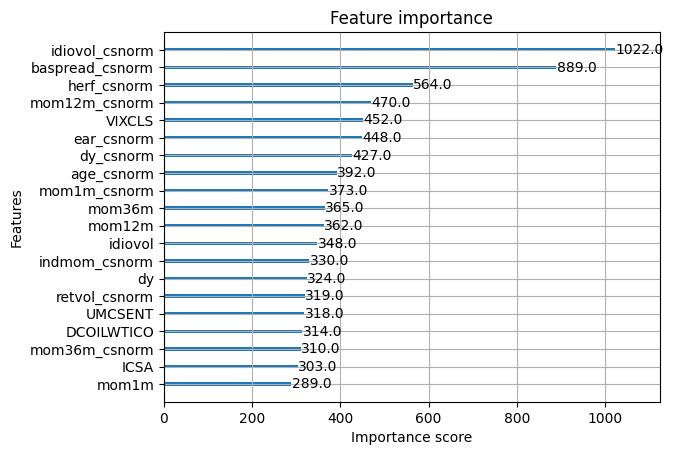

In [141]:
from xgboost import plot_importance

plot_importance(decile_rank_model, max_num_features=20)
plt.show()

### Evaluate performance when rebalancing stocks monthly

In [163]:
# Currently, predictions are for the NEXT month end
pred = test[["ticker", "month_end", "pred_decile_rank"]].copy()
pred["month_end"] = pred["month_end"] + pd.offsets.MonthEnd(1)

min_test_month_end = pred["month_end"].min()

# Shift month end forward 1 month before merging to align with predictions in next month
daily_eval = daily.loc[daily["date"] >= min_test_month_end, ["date", "ticker", "close"]].copy()

daily_eval["month_end"] = pd.to_datetime(daily_eval["date"]) + pd.offsets.MonthEnd(0)
daily_eval = daily_eval.merge(pred, on=["ticker", "month_end"], how="inner")


In [164]:
daily_eval.isna().sum()

date                0
ticker              0
close               0
month_end           0
pred_decile_rank    0
dtype: int64

In [247]:
import importlib
import src.backtest.strategies as bt_strats
import src.backtest.engine as bt_engine

importlib.reload(bt_strats)
importlib.reload(bt_engine)

from src.backtest.strategies import LongOnlyTopPct, LongShortTopBottom
from src.backtest.engine import Backtester

In [213]:
strategy = LongOnlyTopPct(
    pred_col="pred_decile_rank",
    top_pct=0.1,
    date_col="month_end",
    ticker_col="ticker",
)

bt = Backtester(
    data=daily_eval,
    strategy=strategy,
    rebalance_frequency="monthly",
    date_col="month_end",
    ticker_col="ticker",
    price_col="close",
    benchmark_ticker="SPY",
)


# Run backtest
print('Running backtest...')
result_long = bt.run()
print('Backtest complete!')

# Print performance metrics
print_metrics_comparison(
    result_long.metrics,
    result_long.benchmark_metrics,
    strategy_name='Long-Only Top 10%',
    benchmark_name='SPY'
)

Running backtest...
Backtest complete!


In [214]:
# Print performance metrics
print_metrics_comparison(
    result_long.metrics,
    result_long.benchmark_metrics,
    strategy_name='Long-Only Top 10%',
    benchmark_name='SPY'
)


Metric                       Long-Only Top 10%                  SPY
Annual Return                           27.66%               16.19%
Volatility                              16.53%               10.26%
Sharpe Ratio                              1.49                 1.47
Max Drawdown                           -13.84%               -7.97%
CAGR                                    26.05%               15.61%
Calmar Ratio                              1.88                 1.96
Win Rate                                68.00%               64.00%
Avg Turnover                            54.60%                    -
Alpha (Annual)                          25.49%                    -
Beta                                     -0.05                    -
Information Ratio                         0.49                    -
Tracking Error                          19.74%                    -



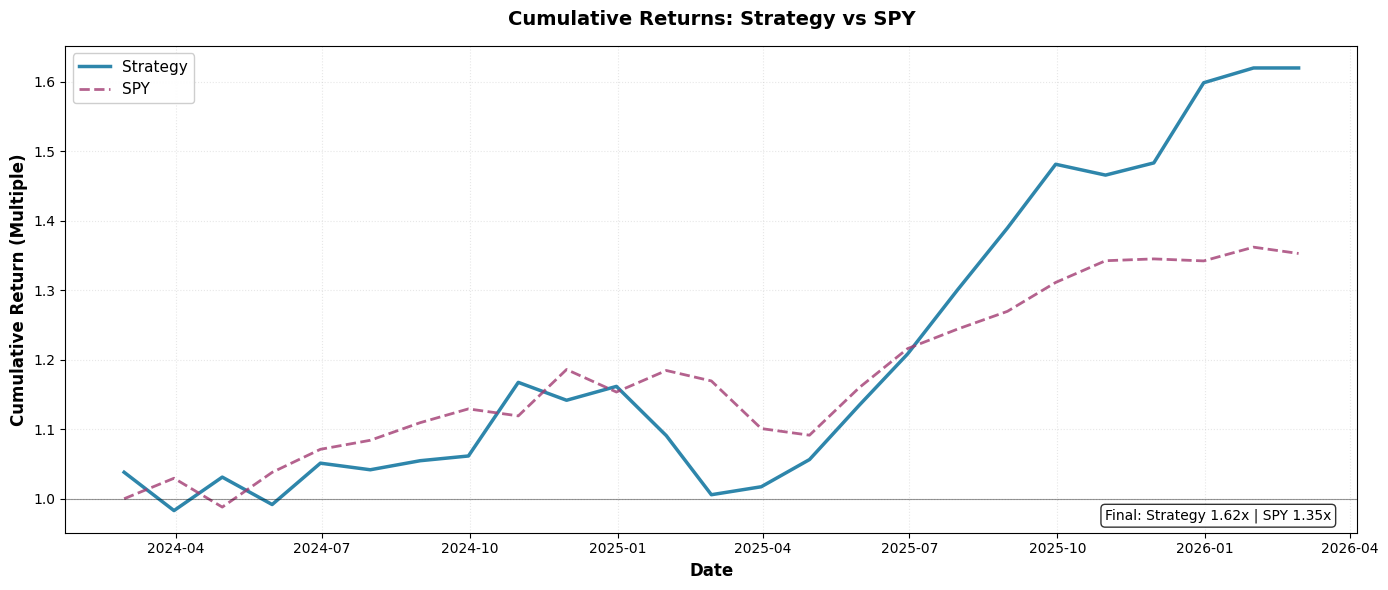

In [257]:
# Plot cumulative returns
plot_cumulative_returns(result_long, benchmark_name='SPY')
plt.show()

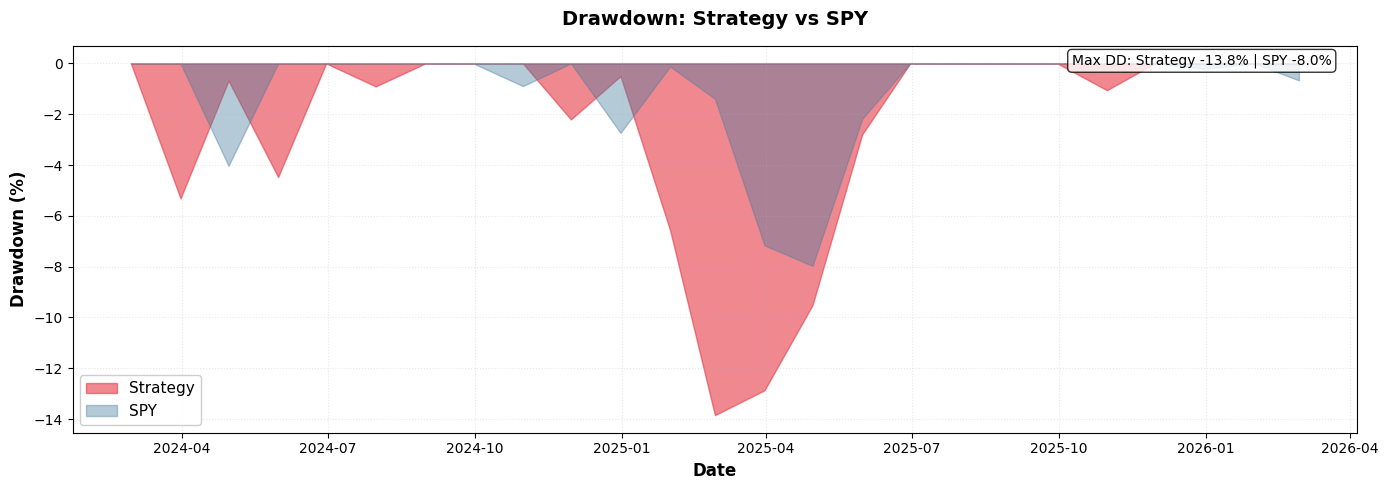

In [215]:
# Plot drawdown
plot_drawdown(result_long, benchmark_name='SPY')
plt.show()

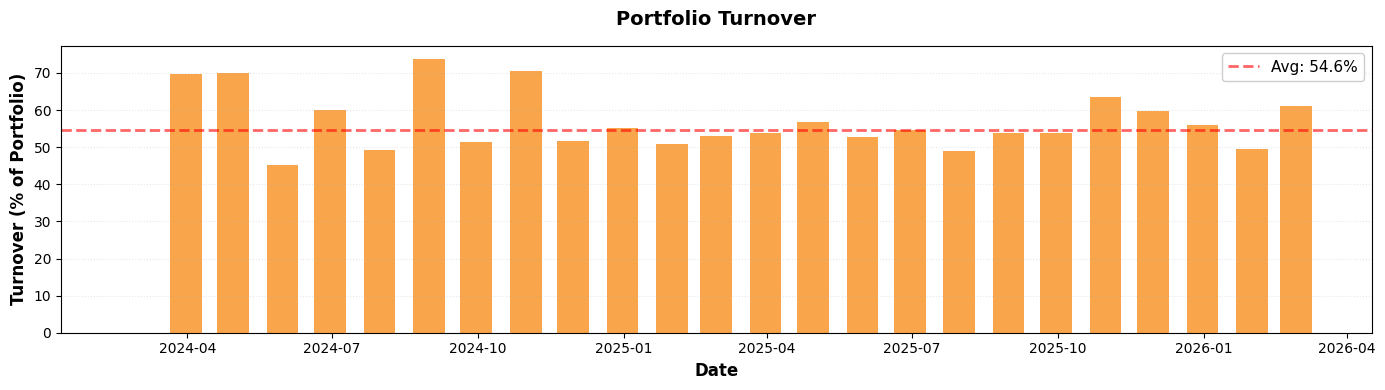

In [207]:
# Plot turnover
plot_turnover(result_long)
plt.show()

In [210]:
# Inspect positions
print('Sample positions from last rebalance:')
# last_date = result_long.positions['date'].max()
last_date = result_long.positions["date"].sort_values().unique()[-1]
last_positions = result_long.positions[result_long.positions['date'] == last_date]
print(f'\nDate: {last_date}')
print(f'Number of holdings: {len(last_positions)}')
print(f'\nTop 10 positions by value:')
last_positions.nsmallest(10, 'shares')[['ticker', 'weight', 'shares', 'price', 'position_value']]

Sample positions from last rebalance:

Date: 2026-02-28 00:00:00
Number of holdings: 571

Top 10 positions by value:


,ticker,weight,shares,price,position_value
15043,GEV,0.001751,0.322445,879.729980,283.664882
15341,SNDK,0.001751,0.444254,638.520020,283.664882
15184,FN,0.001751,0.484177,585.869995,283.664882
15434,POWL,0.001751,0.507305,559.159973,283.664882
15177,STRL,0.001751,0.617038,459.720001,283.664882
15431,NVMI,0.001751,0.623412,455.019989,283.664882
15216,SITM,0.001751,0.700770,404.790009,283.664882
15207,STX,0.001751,0.716289,396.019989,283.664882
15350,PRAX,0.001751,0.827711,342.709991,283.664882
15003,CIEN,0.001751,0.827735,342.700012,283.664882


In [258]:
# Define strategy
strategy_ls = LongShortTopBottom(
    pred_col='pred_decile_rank',
    long_pct=0.10,
    short_pct=0.10, # Change ratio based on market conditions
    dollar_neutral=False,
    date_col="month_end",
    ticker_col="ticker",
    price_col="close",
    min_price=5.0,      # stricter than default
)

backtester_ls = Backtester(
    data=daily_eval,
    strategy=strategy_ls,
    date_col="month_end",
    ticker_col="ticker",
    price_col="close",
    initial_capital=10000,
    # periodic_contribution=1000,  # add $1,000 every rebalance
    # buying_power_multiplier=1.00,
    transaction_cost_bps=30,
    short_term_tax_rate=0.35,
    borrow_cost_annual=0.03,
    rebalance_frequency='monthly',
    benchmark_ticker='SPY',
    missing_price_mode='carry',
    max_abs_ticker_return=2.0,   # +/- 200% monthly cap
    liquidation_floor=-0.95,
)

# Run backtest
print('Running backtest...')
result_ls = backtester_ls.run()
print('Backtest complete!')

# Print performance metrics
print_metrics_comparison(
    result_ls.metrics,
    result_ls.benchmark_metrics,
    strategy_name='Long/Short (10/10)',
    benchmark_name='SPY'
)

Running backtest...
Backtest complete!

Metric                     Long/Short (10/2.5)                  SPY
Annual Return                           18.50%               16.19%
Volatility                               5.11%               10.26%
Sharpe Ratio                              3.35                 1.47
Max Drawdown                            -1.94%               -7.97%
CAGR                                    18.36%               15.61%
Calmar Ratio                              9.48                 1.96
Win Rate                                84.00%               64.00%
Avg Turnover                            48.77%                    -
Alpha (Annual)                          17.66%                    -
Beta                                     -0.04                    -
Information Ratio                         0.17                    -
Tracking Error                          11.80%                    -



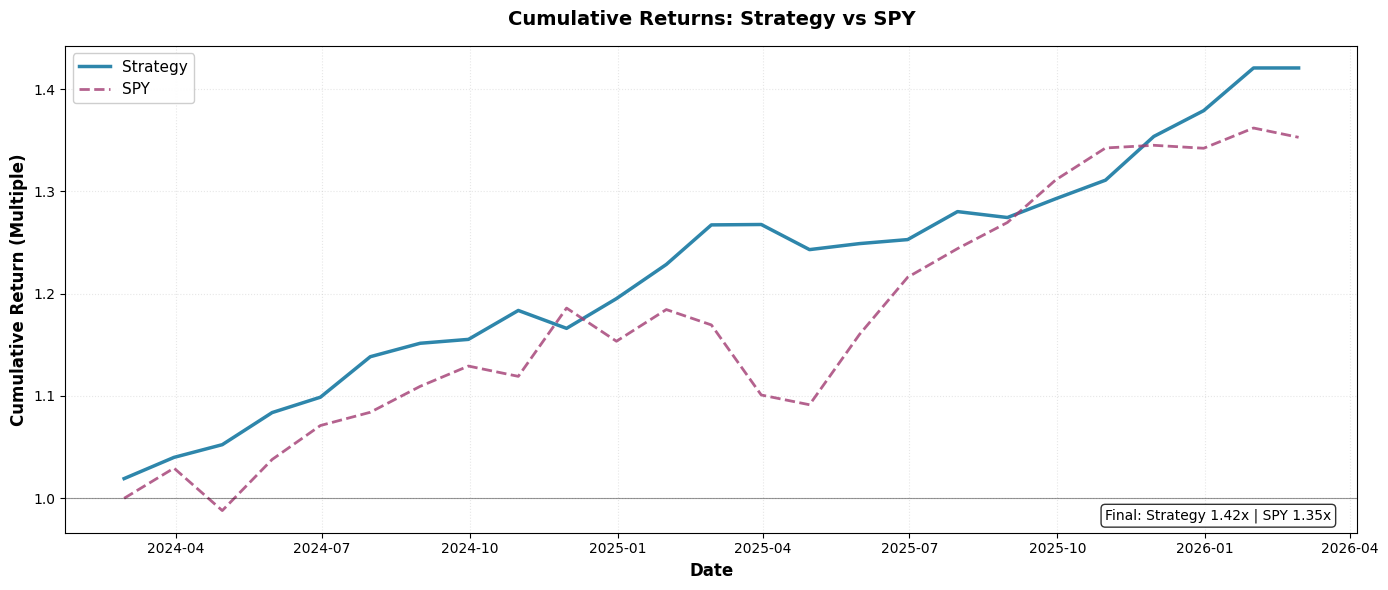

In [259]:
# Plot cumulative returns
plot_cumulative_returns(result_ls, benchmark_name='SPY')
plt.show()

## 2) Multi-class model (3 classes only)

In [309]:
def create_3class_target(df, return_col):
    def classify(group):
        pct_rank = group[return_col].rank(pct=True)

        # Bottom 10%
        bottom = pct_rank <= 0.10

        # Top 10%
        top = pct_rank >= 0.90

        # Default middle
        labels = pd.Series(1, index=group.index)

        labels[bottom] = 0
        labels[top] = 2

        return labels

    return df.groupby("month_end", group_keys=False).apply(classify)

model_df[return_col + "_3class"] = create_3class_target(model_df, return_col)

model_df[return_col + "_3class"].value_counts(dropna=False, normalize=True)

target_excess_t+1_3class
1    0.799936
2    0.100233
0    0.099831
Name: proportion, dtype: float64

In [311]:
target = return_col + "_3class"

# XGBoost classifier
class3_rank_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    missing=np.nan,
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42, 
    callbacks=[
        xgb.callback.EarlyStopping(
            rounds=25,
            save_best=True
        )
    ]
)

class3_rank_model.fit(
    train.loc[train[return_col].notna(), feature_cols],
    train.loc[train[return_col].notna(), return_col + "_bins"], 
    eval_set=[(
        val.loc[val[return_col].notna(), feature_cols],
        val.loc[val[return_col].notna(), return_col + "_bins"]
    )],
    verbose=20,
)

model_df['pred_3class_rank'] = class3_rank_model.predict(model_df[feature_cols], iteration_range=(0, class3_rank_model.best_iteration))
val['pred_3class_rank'] = class3_rank_model.predict(val[feature_cols], iteration_range=(0, class3_rank_model.best_iteration))
test['pred_3class_rank'] = class3_rank_model.predict(test[feature_cols], iteration_range=(0, class3_rank_model.best_iteration))

[0]	validation_0-mlogloss:2.29020
[20]	validation_0-mlogloss:2.20052
[40]	validation_0-mlogloss:2.18817
[60]	validation_0-mlogloss:2.18786
[80]	validation_0-mlogloss:2.18933
[81]	validation_0-mlogloss:2.18957


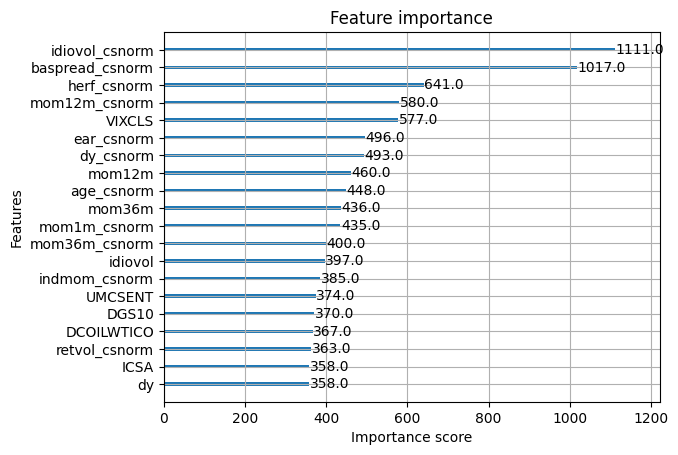

In [316]:
plot_importance(class3_rank_model, max_num_features=20)
plt.show()

### Backtest 3-bucket strategy 

In [317]:
# Currently, predictions are for the NEXT month end
pred = test[["ticker", "month_end", "pred_3class_rank"]].copy()
pred["month_end"] = pred["month_end"] + pd.offsets.MonthEnd(1)

min_test_month_end = pred["month_end"].min()

daily_eval = daily_eval.merge(pred, on=["ticker", "month_end"], how="inner")

In [318]:
strategy = LongOnlyTopPct(
    pred_col="pred_3class_rank",
    top_pct=0.1,
    date_col="month_end",
    ticker_col="ticker",
)

bt = Backtester(
    data=daily_eval,
    strategy=strategy,
    rebalance_frequency="monthly",
    date_col="month_end",
    ticker_col="ticker",
    price_col="close",
    benchmark_ticker="SPY",
)


# Run backtest
print('Running backtest...')
result_long = bt.run()
print('Backtest complete!')

# Print performance metrics (27.66% return for decile rank model)
print_metrics_comparison(
    result_long.metrics,
    result_long.benchmark_metrics,
    strategy_name='Long-Only Top 10%',
    benchmark_name='SPY'
)

Running backtest...
Backtest complete!

Metric                       Long-Only Top 10%                  SPY
Annual Return                           16.25%               16.19%
Volatility                              13.03%               10.26%
Sharpe Ratio                              1.16                 1.47
Max Drawdown                           -12.56%               -7.97%
CAGR                                    15.31%               15.61%
Calmar Ratio                              1.22                 1.96
Win Rate                                76.00%               64.00%
Avg Turnover                            57.31%                    -
Alpha (Annual)                          18.36%                    -
Beta                                     -0.21                    -
Information Ratio                         0.00                    -
Tracking Error                          17.88%                    -



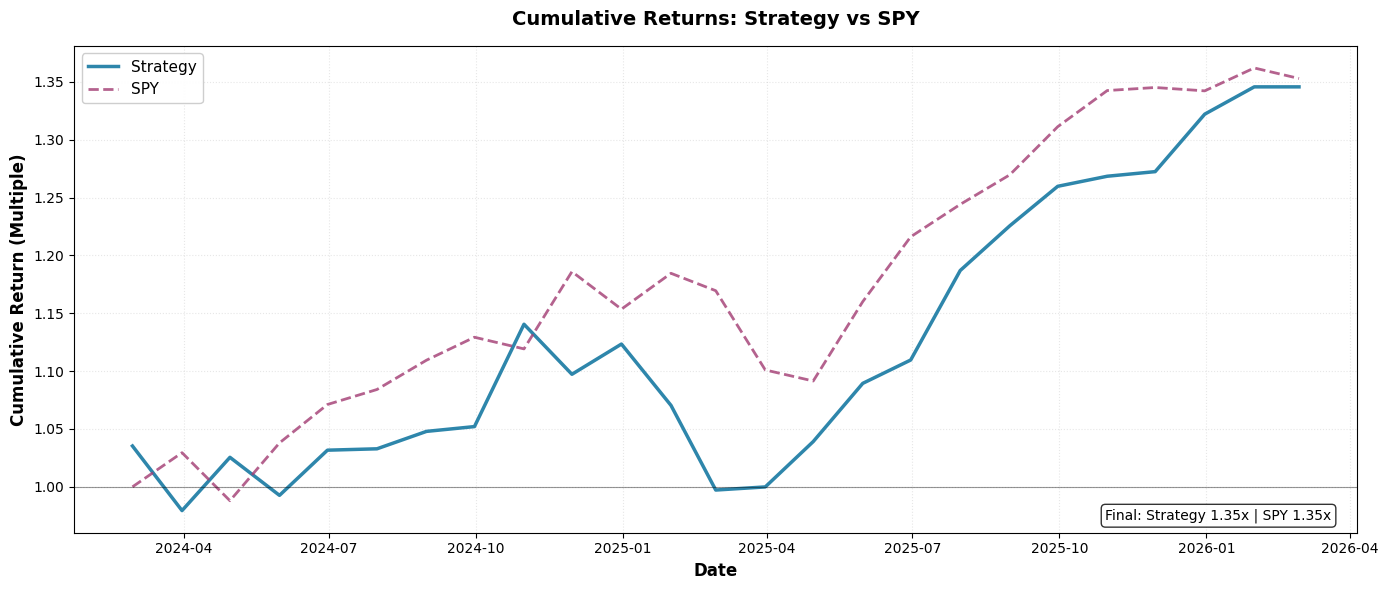

In [319]:
# Plot cumulative returns
plot_cumulative_returns(result_long, benchmark_name='SPY')
plt.show()

### Long Short (10/10) Test with 3 buckets

In [320]:
# Define strategy
strategy_ls = LongShortTopBottom(
    pred_col='pred_3class_rank',
    long_pct=0.10,
    short_pct=0.10, # Change ratio based on market conditions
    dollar_neutral=False,
    date_col="month_end",
    ticker_col="ticker",
    price_col="close",
    min_price=5.0,      # stricter than default
)

backtester_ls = Backtester(
    data=daily_eval,
    strategy=strategy_ls,
    date_col="month_end",
    ticker_col="ticker",
    price_col="close",
    initial_capital=10000,
    # periodic_contribution=1000,  # add $1,000 every rebalance
    # buying_power_multiplier=1.00,
    transaction_cost_bps=30,
    short_term_tax_rate=0.35,
    borrow_cost_annual=0.03,
    rebalance_frequency='monthly',
    benchmark_ticker='SPY',
    missing_price_mode='carry',
    max_abs_ticker_return=2.0,   # +/- 200% monthly cap
    liquidation_floor=-0.95,
)

# Run backtest
print('Running backtest...')
result_ls = backtester_ls.run()
print('Backtest complete!')

# Print performance metrics
print_metrics_comparison(
    result_ls.metrics,
    result_ls.benchmark_metrics,
    strategy_name='Long/Short (10/10)',
    benchmark_name='SPY'
)

Running backtest...
Backtest complete!

Metric                      Long/Short (10/10)                  SPY
Annual Return                           17.59%               16.19%
Volatility                               4.83%               10.26%
Sharpe Ratio                              3.38                 1.47
Max Drawdown                            -1.15%               -7.97%
CAGR                                    17.46%               15.61%
Calmar Ratio                             15.19                 1.96
Win Rate                                76.00%               64.00%
Avg Turnover                            46.87%                    -
Alpha (Annual)                          17.29%                    -
Beta                                     -0.06                    -
Information Ratio                         0.10                    -
Tracking Error                          11.92%                    -



## Regression model

In [277]:
# Create dmatrix and drop NaN values
dtrain = xgb.DMatrix(
    train[feature_cols], 
    label=train[return_col],
    enable_categorical=True
)

In [299]:
# Make predictions on test set
dtest = xgb.DMatrix(test[feature_cols], enable_categorical=True)

# XGBoost Regression model
params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.01,
    "max_depth": 2,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "colsample_bylevel": 0.7,
    "min_child_weight": 1,
    "tree_method": "hist",
    "seed": 42
}

reg_model = xgb.train(
    params,
    dtrain,
    evals=[
        (
            xgb.DMatrix(
                val[feature_cols], 
                label= val[return_col], 
                enable_categorical=True
            ), 
            "validation"
        )
    ],
    num_boost_round=500, 
    verbose_eval=5, 
    early_stopping_rounds=25
)

# Make predictions on test set
test['pred_reg'] = reg_model.predict(dtest, iteration_range=(0, reg_model.best_iteration))

[0]	validation-rmse:0.14533
[5]	validation-rmse:0.14521
[10]	validation-rmse:0.14508
[15]	validation-rmse:0.14502
[20]	validation-rmse:0.14496
[25]	validation-rmse:0.14493
[30]	validation-rmse:0.14490
[35]	validation-rmse:0.14491
[40]	validation-rmse:0.14496
[45]	validation-rmse:0.14501
[50]	validation-rmse:0.14509
[54]	validation-rmse:0.14517


In [301]:
test.groupby(pd.qcut(test['pred_reg'], 3))[return_col].mean()

pred_reg
(-0.015099999999999999, -0.00771]   -0.006768
(-0.00771, -0.00736]                 0.014426
(-0.00736, -0.00208]                -0.010256
Name: target_excess_t+1, dtype: float64

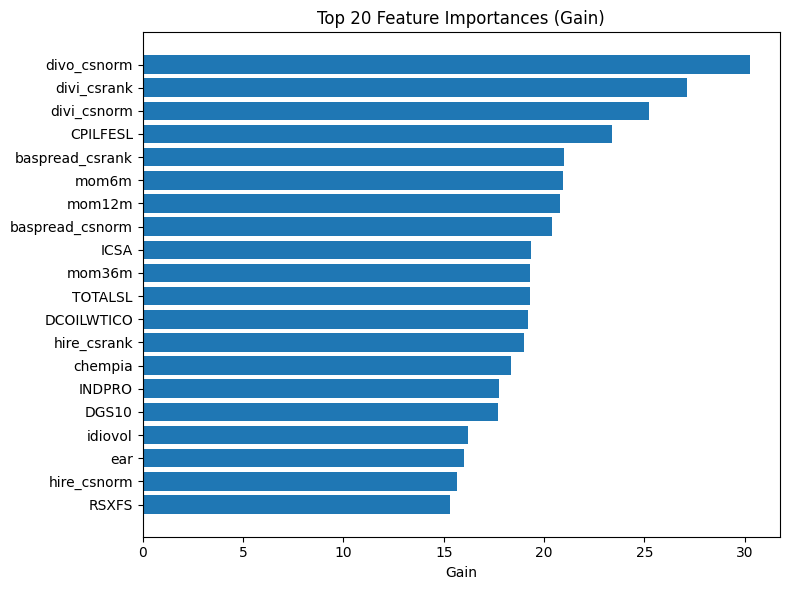

In [302]:
# Get importance dictionary
importance = reg_model.get_score(importance_type="gain")

# Convert to DataFrame
importance_df = (
    pd.DataFrame(
        list(importance.items()),
        columns=["feature", "importance"]
    )
    .sort_values("importance", ascending=False)
)

# Plot
plt.figure(figsize=(8,6))
plt.barh(
    importance_df["feature"][:20][::-1],
    importance_df["importance"][:20][::-1]
)
plt.title("Top 20 Feature Importances (Gain)")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()

